In [3]:
import numpy as np
import pandas as pd

from datetime import datetime
from scipy.stats import skew 
from scipy.special import boxcox1p
from scipy.stats import boxcox_normmax
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from mlxtend.regressor import StackingCVRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import matplotlib.pyplot as plt
import scipy.stats as stats
import sklearn.linear_model as linear_model
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KDTree
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


import os
print(os.listdir())

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from quantile_forest import RandomForestQuantileRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

random_state = 0
np.random.seed(random_state)

['house_price_competition_day_2_failed_trying.ipynb', 'house_price_advanced_view.ipynb', 'addr_kmeans.pkl', 'submission.csv', 'house_price_advanced_models.ipynb', 'my_model_submission.csv1', 'my_model_submission4.csv', 'house_price', 'addr_umap.pkl', 'Day1.ipynb', 'titanic', 'house-prices-advanced-regression-techniques.zip', 'titanic.zip', 'my_model_submission3.csv', 'house_price_competition_view_day2.ipynb', 'Untitled.ipynb', 'my_model_submission0.csv', 'X_umap.npy', 'addr_tfidf.pkl', 'Day2 Housing Price.ipynb', 'pca_model.pkl', 'my_model_submission.csv', 'predictions.csv', 'umap_model.pkl', 'predictions4.csv', 'my_model_submission1.csv', 'competition_day7.ipynb', 'Untitled1.ipynb', 'house_price_view.ipynb', 'home-data-for-ml-course.zip', 'Untitled2.ipynb', '.ipynb_checkpoints', 'home-data-for-ml-course', 'house_price.ipynb', 'predictions3.csv', 'my_model_submission2.csv', 'best_interval_model.pth', 'predictions2.csv']


In [4]:
train = pd.read_csv('house_price/dataset.csv')
test = pd.read_csv('house_price/test.csv')
print ("Data is loaded!")

Data is loaded!


In [5]:
quantitative = [f for f in train.columns if train.dtypes[f] != 'object']
quantitative.remove('sale_price')
quantitative.remove('id')
qualitative = [f for f in train.columns if train.dtypes[f] == 'object']

In [6]:
def dataset_fill_null(obj):
    obj['subdivision'].fillna('Unknown', inplace=True)
    obj.drop(columns=['sale_nbr'], inplace=True)
    obj['submarket'].fillna('Unknown', inplace=True)

missing = train.isnull().sum()
missing = missing[missing > 0]
print(missing)

dataset_fill_null(train)
dataset_fill_null(test)
print(train.shape)
print(test.shape)

sale_nbr       42182
subdivision    17550
submarket       1717
dtype: int64
(200000, 46)
(200000, 45)


In [7]:
# 构造原始地址字段
train_ID = train['id']
test_ID = test['id']
# Now drop the  'Id' colum since it's unnecessary for  the prediction process.
train.drop(['id'], axis=1, inplace=True)
test.drop(['id'], axis=1, inplace=True)
# Deleting outliers
train.reset_index(drop=True, inplace=True)
# We use the numpy fuction log1p which  applies log(1+x) to all elements of the column
train["sale_price"] = np.log1p(train["sale_price"])
y = train.sale_price.reset_index(drop=True)

In [8]:
def preprocess_and_encode(df, y=None, drop_high_card=True):
    df = df.copy()
    
    # ================= 清洗阶段 ================= #
    addresses = (df['city'].fillna('') + ' ' + df['subdivision'].fillna('')).str.lower()
    
    # 分词（空格切）
    # 用 CountVectorizer 可以保留频率稀疏性
    
    vectorizer = CountVectorizer(
        max_features=1000,         # 可调大小
        stop_words=None,      # 去常见词
        token_pattern=r'\b\w+\b',  # 标准单词
        ngram_range=(1, 2)         # 一元和二元组都试试
    )
    address_vecs = vectorizer.fit_transform(addresses)
    
    address_df = pd.DataFrame(address_vecs.toarray(), columns=vectorizer.get_feature_names_out())
    address_df.index = df.index
    df = pd.concat([df, address_df], axis=1)
    df = df.drop(columns=['city', 'subdivision'])

    # 使用同一个 address_vecs（CountVectorizer 输出）
    svd = TruncatedSVD(n_components=50, random_state=42)
    address_pca = svd.fit_transform(address_vecs)
    
    # 转成 DataFrame 并拼接
    pca_df = pd.DataFrame(address_pca, columns=[f'address_pca_{i+1}' for i in range(address_pca.shape[1])], index=df.index)
    df = pd.concat([df, pca_df], axis=1)

    # 补充缺失类别为 'None'
    cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns
    
    for col in cat_cols:
        df[col] = df[col].fillna('None')

    # 填充数值缺失为 0
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        df[col] = df[col].fillna(0)

    # 拆解日期特征
    if 'sale_date' in df.columns:
        df['sale_date'] = pd.to_datetime(df['sale_date'])
        df['sale_year'] = pd.to_datetime(df['sale_date']).dt.year
        df['sale_month'] = pd.to_datetime(df['sale_date']).dt.month
        df['house_age'] = df['sale_year'] - df['year_built']
        df['reno_age'] = df['sale_year'] - df['year_reno']
        df['has_reno'] = (df['year_reno'] > 0).astype(int)
        df['land_imp_ratio'] = df['land_val'] / (df['imp_val'] + 1e-5)
        df['time_since_sale'] = (df['sale_date'].max() - df['sale_date']).dt.days / 30  # 单位：月        
        df = df.drop(columns='sale_date')





    # ================= 编码阶段 ================= #
    cat_cols = df.select_dtypes(include='object').columns
    low_card_cols = []
    high_card_cols = []
    
    for col in cat_cols:
        try:
            n_unique = df[col].nunique()
            if isinstance(n_unique, (int, np.integer)):
                if n_unique <= 50:
                    low_card_cols.append(col)
                else:
                    high_card_cols.append(col)
            else:
                print(f"[跳过] {col} 的 nunique 结果不是标量: {n_unique}")
        except Exception as e:
            print(f"[异常] {col}: {e}")


    # One-hot 编码
    X_cat = pd.get_dummies(df[low_card_cols], dummy_na=True)

    # Target 编码
    if y is not None and high_card_cols:
        encoder = ce.TargetEncoder()
        X_target = encoder.fit_transform(df[high_card_cols], y)
        X_target.columns = [f"{col}_te" for col in high_card_cols]
    else:
        X_target = pd.DataFrame(index=df.index)

    # 拼接所有
    X_final_df = pd.concat([X_cat, X_target], axis=1)

    return X_final_df


In [9]:
def add_knn_price_features_radius(
    df, base_df, lat_col='latitude', lon_col='longitude',
    target_col='sale_price', radii=[0.005, 0.01, 0.02], max_neighbors=300
):
    df = df.copy()
    coords_query = df[[lat_col, lon_col]].astype(np.float64).values
    coords_base = base_df[[lat_col, lon_col]].astype(np.float64).values
    targets_base = base_df[target_col].astype(np.float64).values

    tree = KDTree(coords_base, leaf_size=40, metric='euclidean')

    for r in radii:
        neighbor_indices = tree.query_radius(coords_query, r=r)
        
        stats = {
            'mean': [], 'std': [], 'min': [], 'max': [],
            'range': [], 'iqr': [], 'median': [], 'count': []
        }

        for i, inds in enumerate(neighbor_indices):
            if base_df is df:
                inds = inds[inds != i]

            if len(inds) == 0:
                for key in stats:
                    stats[key].append(np.nan if key != 'count' else 0)
            else:
                if len(inds) > max_neighbors:
                    inds = inds[:max_neighbors]
                vals = targets_base[inds]
                stats['mean'].append(np.mean(vals))
                stats['std'].append(np.std(vals))
                stats['min'].append(np.min(vals))
                stats['max'].append(np.max(vals))
                stats['range'].append(np.max(vals) - np.min(vals))
                stats['iqr'].append(np.percentile(vals, 75) - np.percentile(vals, 25))
                stats['median'].append(np.median(vals))
                stats['count'].append(len(inds))

        for key in stats:
            df[f'knn_radius_{key}_r{r}'] = stats[key]

    return df


def add_knn_price_features(df, base_df=None, lat_col='latitude', lon_col='longitude',
                           target_col='target', ks=[5, 10, 20]):
    if base_df is None:
        base_df = df  # 默认自己为近邻池

    coords_query = df[[lat_col, lon_col]].values
    coords_base = base_df[[lat_col, lon_col]].values
    tree = KDTree(coords_base, metric='euclidean')

    base_targets = base_df[target_col].values
    knn_features = {}

    for k in ks:
        dists, indices = tree.query(coords_query, k=k)
        neighbor_targets = base_targets[indices]

        knn_features[f'knn_price_mean_{k}'] = neighbor_targets.mean(axis=1)
        knn_features[f'knn_price_std_{k}'] = neighbor_targets.std(axis=1)
        knn_features[f'knn_price_range_{k}'] = neighbor_targets.max(axis=1) - neighbor_targets.min(axis=1)

    for col, val in knn_features.items():
        df[col] = val

    return df


In [10]:
# 应用预处理
# 对训练集（自己做自己）
train = add_knn_price_features(train, base_df=train, target_col='sale_price')
# 对测试集（用训练集做 base）
test = add_knn_price_features(test, base_df=train, target_col='sale_price')

train = add_knn_price_features_radius(train, base_df=train, target_col='sale_price')
# 对测试集（用训练集做 base）
test = add_knn_price_features_radius(test, base_df=train, target_col='sale_price')

# train_features = train.drop(['sale_price'], axis=1)
test_features = test

features = pd.concat([train_features, test_features]).reset_index(drop=True)
print(features.shape)
print([col for col in features.columns if 'knn' in col])

X_final = preprocess_and_encode(features)

(400000, 77)
['knn_price_mean_5', 'knn_price_std_5', 'knn_price_range_5', 'knn_price_mean_10', 'knn_price_std_10', 'knn_price_range_10', 'knn_price_mean_20', 'knn_price_std_20', 'knn_price_range_20', 'knn_radius_mean_r0.005', 'knn_radius_std_r0.005', 'knn_radius_min_r0.005', 'knn_radius_max_r0.005', 'knn_radius_range_r0.005', 'knn_radius_iqr_r0.005', 'knn_radius_median_r0.005', 'knn_radius_count_r0.005', 'knn_radius_mean_r0.01', 'knn_radius_std_r0.01', 'knn_radius_min_r0.01', 'knn_radius_max_r0.01', 'knn_radius_range_r0.01', 'knn_radius_iqr_r0.01', 'knn_radius_median_r0.01', 'knn_radius_count_r0.01', 'knn_radius_mean_r0.02', 'knn_radius_std_r0.02', 'knn_radius_min_r0.02', 'knn_radius_max_r0.02', 'knn_radius_range_r0.02', 'knn_radius_iqr_r0.02', 'knn_radius_median_r0.02', 'knn_radius_count_r0.02']


In [11]:
X = X_final.iloc[:len(train_features)].reset_index(drop=True)
X_sub = X_final.iloc[len(train_features):].reset_index(drop=True)
print('X', X.shape, 'y', y.shape, 'X_sub', X_sub.shape)

protected_cols = []
overfit = [i for i in X.columns if i not in protected_cols and X[i].value_counts().iloc[0] / len(X) * 100 > 99.94]
print(overfit)

X = X.drop(overfit, axis=1)
X_sub = X_sub.drop(overfit, axis=1)
print('X', X.shape, 'y', y.shape, 'X_sub', X_sub.shape)

X (200000, 30) y (200000,) X_sub (200000, 30)
['join_status_nan', 'submarket_nan']
X (200000, 28) y (200000,) X_sub (200000, 28)


In [15]:
alpha = 0.1

In [16]:
def winkler_score(y_true, lower, upper, alpha=0.1, return_coverage=False):
    """Compute the Winkler Interval Score for prediction intervals.

    Args:
        y_true (array-like): True observed values.
        lower (array-like): Lower bounds of prediction intervals.
        upper (array-like): Upper bounds of prediction intervals.
        alpha (float): Significance level (e.g., 0.1 for 90% intervals).
        return_coverage (bool): If True, also return empirical coverage.

    Returns:
        score (float): Mean Winkler Score.
        coverage (float, optional): Proportion of true values within intervals.
    """
    y_true = np.asarray(y_true)
    lower = np.asarray(lower)
    upper = np.asarray(upper)

    width = upper - lower
    penalty_lower = 2 / alpha * (lower - y_true)
    penalty_upper = 2 / alpha * (y_true - upper)

    score = width.copy()
    score += np.where(y_true < lower, penalty_lower, 0)
    score += np.where(y_true > upper, penalty_upper, 0)

    if return_coverage:
        inside = (y_true >= lower) & (y_true <= upper)
        coverage = np.mean(inside)
        return np.mean(score), coverage

    return np.mean(score)

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=random_state
)
X_test = X_sub.copy()

In [18]:
qrf = RandomForestQuantileRegressor(
    n_estimators=100,
    max_features=0.333,
    max_samples_leaf=1,
    random_state=random_state,
)
qrf.fit(X_train, y_train)

,n_estimators,100
,default_quantiles,0.5
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,0.333
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [19]:
quantiles = [alpha / 2, 1 - alpha / 2]

y_val_pred = qrf.predict(X_val, quantiles=quantiles)
y_val_pred = pd.DataFrame(y_val_pred, columns=["pi_lower", "pi_upper"])

In [20]:
mws, coverage = winkler_score(
    y_val,
    y_val_pred["pi_lower"],
    y_val_pred["pi_upper"],
    alpha=alpha,
    return_coverage=True,
)

print("Mean Winkler Score:", round(mws, 2))
print("Coverage:", round(coverage * 100, 1), "%")

Mean Winkler Score: 2.09
Coverage: 88.4 %


                         Feature  Importance
16                   submarket_I    0.103249
3              join_status_nochg    0.103167
26                   submarket_S    0.092122
11                   submarket_D    0.087431
19                   submarket_L    0.080452
25                   submarket_R    0.066587
18                   submarket_K    0.053063
5   join_status_rebuilt - before    0.048906
22                   submarket_O    0.044104
17                   submarket_J    0.041103


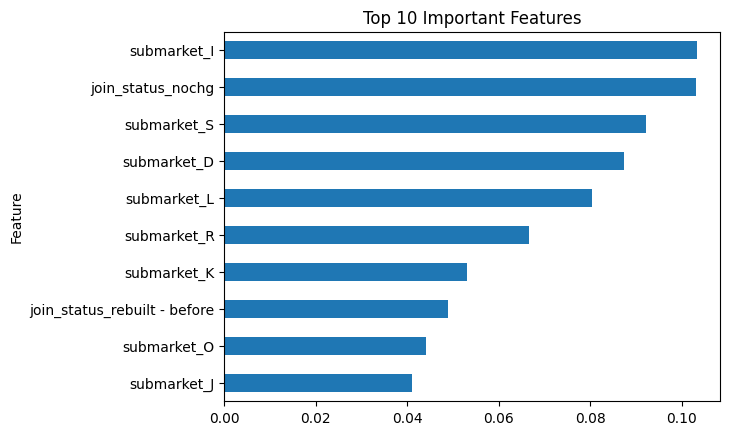

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 模型是 qrf
feature_importances = qrf.feature_importances_
features = X_train.columns  # 或你使用的特征列名

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 打印前十个最重要的特征
print(importance_df.head(10))

# 可视化
importance_df.head(10).plot(kind='barh', x='Feature', y='Importance', legend=False)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


<Axes: xlabel='knn_price_mean_10', ylabel='sale_price'>

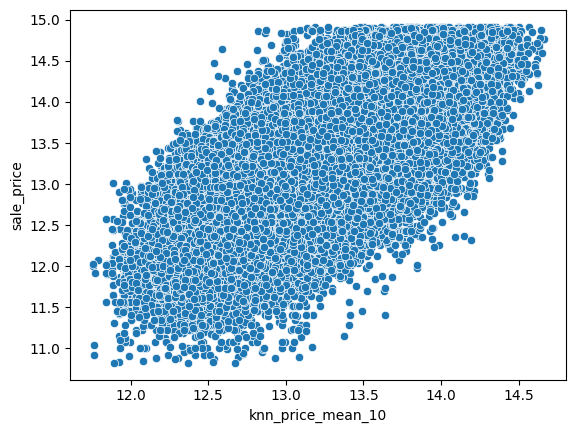

In [23]:
from sklearn.inspection import permutation_importance

# 用 LightGBM 拟合后做 permutation importance
result = permutation_importance(qrf, X_val, y_val, n_repeats=10, random_state=42)
sorted_idx = result.importances_mean.argsort()[::-1]
top_features = X_val.columns[sorted_idx][:20]
import seaborn as sns
sns.scatterplot(data=train, x='knn_price_mean_10', y='sale_price')
